Current Directory:
/workspaces/codespaces-jupyter/notebooks/models
Model files found
Model loaded successfully
Inference engine initialized
Image preprocessing complete
Running face detection...
Inference completed
Face detected
Confidence: 0.89
Inference Summary Report
Faces Detected: 1


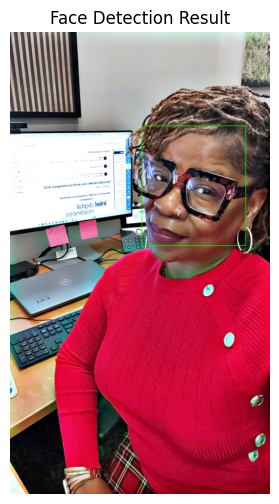

In [ ]:
# =====================================
# Face Detection using OpenVINO solution
# Programming Exercise 7-2: Face Detection with OpenVINO
# =====================================

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from openvino.runtime import Core

# -------------------------------------
# Step 1: Show Working Directory
# -------------------------------------

print("Current Directory:")
print(os.getcwd())

# -------------------------------------
# Step 2: Model Paths
# -------------------------------------

model_xml = "face-detection-adas-0001.xml"
model_bin = "face-detection-adas-0001.bin"

if not os.path.exists(model_xml):
    raise ValueError("XML model file not found")

if not os.path.exists(model_bin):
    raise ValueError("BIN model file not found")

print("Model files found")

# -------------------------------------
# Step 3: Load Model
# -------------------------------------

core = Core()

model = core.read_model(
    model=model_xml,
    weights=model_bin
)

print("Model loaded successfully")

# -------------------------------------
# Step 4: Compile Model
# -------------------------------------

compiled_model = core.compile_model(model, "CPU")

print("Inference engine initialized")

# -------------------------------------
# Step 5: Load Image
# -------------------------------------

image_path = "test_face.jpg"

input_image = cv2.imread(image_path)

if input_image is None:
    raise ValueError("Test image not found")

# Model input size
H, W = 384, 672

# Resize image
resized_image = cv2.resize(input_image, (W, H))

# Convert HWC → CHW format
image_tensor = np.transpose(resized_image, (2,0,1))
image_tensor = np.expand_dims(image_tensor, axis=0)

print("Image preprocessing complete")

# -------------------------------------
# Step 6: Run Inference
# -------------------------------------

print("Running face detection...")

results = compiled_model([image_tensor])[compiled_model.output(0)]

print("Inference completed")

# -------------------------------------
# Step 7: Process Detection Results
# -------------------------------------

face_count = 0
CONF_THRESHOLD = 0.5

if len(results) > 0:

    for detection in results[0][0]:

        confidence = float(detection[2])

        if confidence > CONF_THRESHOLD:

            face_count += 1

            xmin = int(detection[3] * input_image.shape[1])
            ymin = int(detection[4] * input_image.shape[0])
            xmax = int(detection[5] * input_image.shape[1])
            ymax = int(detection[6] * input_image.shape[0])

            cv2.rectangle(input_image, (xmin, ymin), (xmax, ymax), (0,255,0), 2)

            print("Face detected")
            print("Confidence:", round(confidence,2))

# -------------------------------------
# Step 8: Output Summary
# -------------------------------------

print("============================")
print("Inference Summary Report")
print("Faces Detected:", face_count)
print("============================")

# -------------------------------------
# Step 9: Display Image
# -------------------------------------

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))
plt.title("Face Detection Result")
plt.axis("off")
plt.show()

In [2]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
/workspaces/codespaces-jupyter/notebooks/models
